# Gini Index

### Imports

In [3]:
from __future__ import annotations
import networkx as nx
import pytest
from abc import ABC, abstractmethod

### Error Classes

In [4]:
class NormalizationError(Exception):
    """Exception raised for errors in the normalization.

    Attributes:
        message -- explanation of the error
    """

    def __init__(self, message="An error occurred during normalization."):
        self.message = message
        super().__init__(self.message)

class NullGraphError(Exception):
    """Exception raised for null graph."""
    pass

class EmptyGraphError(Exception):
    """Exception raised for empty graph. Nodes with no edges."""
    pass


def check_raw_value(func):
    """Decorator to check if raw value is None. If it is, raise an error."""
    def wrapper(self, *args):
        if self._raw_value is not None:
            return func(self, *args)
        else:
            raise ValueError("Raw value is None. Call compute() method first.")
    return wrapper

### Abstract Class

In [5]:
class _Property(ABC):
    """Abstract base class for all properties."""
    _return_type = None
    _use_paths = False
    _use_direction = False
    _use_selfloops = False
    _use_giant_component = False

    def __init__(self, G: nx.DiGraph):
        self.G = G
        self._raw_value = None
        self._n_nodes = self.G.number_of_nodes()
        if self._n_nodes == 0:
            raise NullGraphError("Can not calculate subgraph centrality for inexistent nodes.")

    @abstractmethod
    def compute(self):
        return self._raw_value

    @abstractmethod
    def norm_biol(self, *args):
        pass

    @abstractmethod
    def norm_network(self, *args):
        pass

### Decorators

In [6]:
def use_direction(cls):
    cls._use_direction = True
    return cls

def use_selfloops(cls):
    cls._use_selfloops = True
    return cls

def use_giant_component(cls):
    cls._use_giant_component = True
    return cls

def return_scalar(cls):
    cls._return_type = "scalar"
    return cls

def return_distribution(cls):
    cls._return_type = "distribution"
    return cls

def use_paths(cls):
    cls._use_paths = True
    return cls

### Auxiliar Fxns

In [7]:
def get_parent_nodes(G: nx.DiGraph):
    """Get the parent nodes of a graph."""
    return [i for i, k_out in G.out_degree() if k_out > 0]

### Gini Index Class

The Gini Index measures the relative sparcity of the distribution of reasources between entities in a certain population. For networks, connections are considered as the resources to distribute, and the nodes are the entities in the population, with the entire graph as the population. [https://doi.org/10.1016/j.ins.2018.05.044] It is useful to determine whether or not connections are concentrated between a certain number of nodes or are they equally distributed.

For a complete directed network (number of edges = n^2) and a regular network (all nodes with a constant degree), the Gini Index is equal to 0, meaning a perfect distribution of connections.
As the distribution becomes more and more unequal, the Gini Index increases, reaching a maximal unequal distribution (all resources are allocated to a single node) of 1.

For a biological normalization we have to measure sparcity of distribution of connections between only nodes that could be allocated an outgoing connection, regulators. If a network has an average of 10% of its nodes being regulators, a perfectly equal distribution between them should be equal to a Gini Index of 0, where if all of its nodes are considered in the calculation, the Gini Index would be closer to 1, wrongly meaning an unqeual distribution.

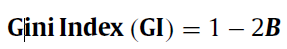

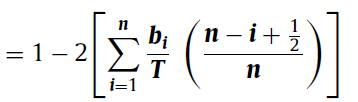

In [43]:
@return_scalar
@use_selfloops
@use_direction
class GiniIndex(_Property):
    """Gini Index.

    Measurement that reflects the inequiality of distribution of resources between entities. For networks, connections are
    considered as resources and each node is an individual entity. Therefore, we calculate how well (Gini Index = 0) or 
    how unequal (Gini Index = 1) the distribution of links between nodes in the network is.
    It is calculated thorugh the area under the curve of The Lorenz Curve, which is drawn by the cummulative percentage of
    total connections which a certain fraction of nodes can have.

    Methods:
        compute: Compute the gini index for the graph.
        norm_biol: Normalize gini index to consider distribution of resources only between regulators.
        norm_network: Already normalized.
    """
    __name__ = 'Gini Index'
    
    def __init__(self, G: nx.DiGraph):
        """
        Args:
            G (nx.DiGraph): Graph.
        """
        super().__init__(G)

    def compute(self) -> float:
        """Compute the gini index for the graph.

        Returns:
            float: gini index of the entire graph.  
        """
        self.t = self.G.number_of_edges()
        if self.t == 0:
            raise EmptyGraphError("There are no edges. Can not calculate Gini Index of a network with no edges.")
        
        b = [j for x,j in self.G.out_degree()]
        b.sort()
        area = 0
        
        for i in range(self._n_nodes):
            x = b[i] / self.t
            y = ((self._n_nodes - (i + 1) + 0.5) / self._n_nodes)
            area += (x * y)
        
        self._raw_value = 1 - (2 * area)
        return self._raw_value

    @check_raw_value
    def norm_biol(self) -> float:
        """Normalization is a recalculation only between nodes with an out-degree higher than 0.
           Resources (connections) should not be distributed equally between all nodes in network, only between regulators"""
        n_parents = len(get_parent_nodes(self.G))
        if n_parents == self._n_nodes:
            return self._raw_value
        
        b = [j for x,j in self.G.out_degree() if j != 0]
        b.sort()
        area = 0
        for i in range(n_parents):
            x = b[i] / self.t
            y = ((n_parents - (i + 1) + 0.5) / n_parents)
            area += (x * y)
        
        self._norm_biol = 1 - (2 * area)
        return self._norm_biol

    @check_raw_value
    def norm_network(self) -> float:
        """Already normalized."""
        return self._raw_value # Already normalized [0,1]

### Testing

In [9]:
# Null graph
G = nx.DiGraph()
with pytest.raises(NullGraphError) as e_info:
    property = GiniIndex(G)

# Empty graph, allows instance from an empty graph, but does not compute
n_nodes= 5
G.add_nodes_from(range(n_nodes))
property = GiniIndex(G)
with pytest.raises(EmptyGraphError) as e_info:
    property.compute()

# add edges
# complete directed graph with self loops
G.add_edges_from([(i, j) for i in range(n_nodes) for j in range(n_nodes)])
property = GiniIndex(G)

assert property.compute() == 0
assert property.norm_network() == 0
assert property.norm_biol() == 0

# add edges
# only half of the nodes are parents and regulate every node in the graph
G = nx.DiGraph()
n_nodes= 5
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i, j) for i in range(n_nodes//2) for j in range(n_nodes)])
property = GiniIndex(G)

assert property.compute() == 0.6 #Resources are perfectly distributed between actual regulators, BUT theoretically every node in the network could be a regulator
assert property.norm_network() == 0.6
assert property.norm_biol() == 0 #Resources are perfectly distributed between regulators